In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

# daaset


In [25]:
dataset_cols = ['bike_count', 'hour', 'temp', 'humidity', 'wind', 'visibility', 'dew_pt_temp',
                'radiation', 'rain', 'snow', 'functional']
df = pd.read_csv("SeoulBikeData.csv", encoding='latin1').drop(['Date', 'Holiday', "Seasons"], axis = 1)

In [26]:
df.columns = dataset_cols
df['functional'] = (df['functional'] == 'Yes').astype(int)
df = df[df["hour"] == 12]
df = df.drop("hour", axis = 1)

In [27]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


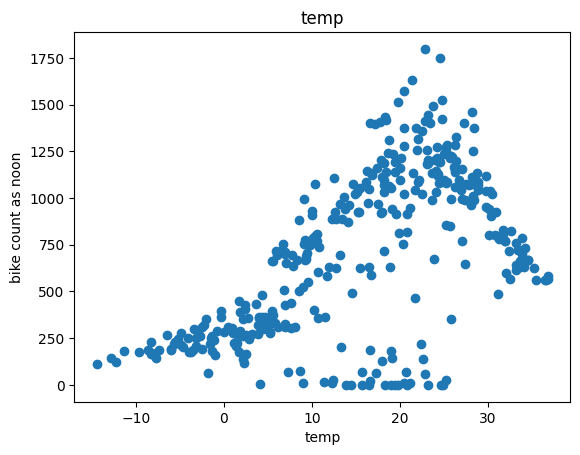

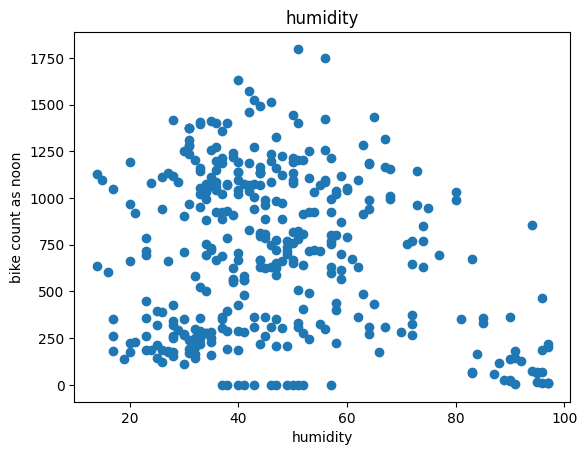

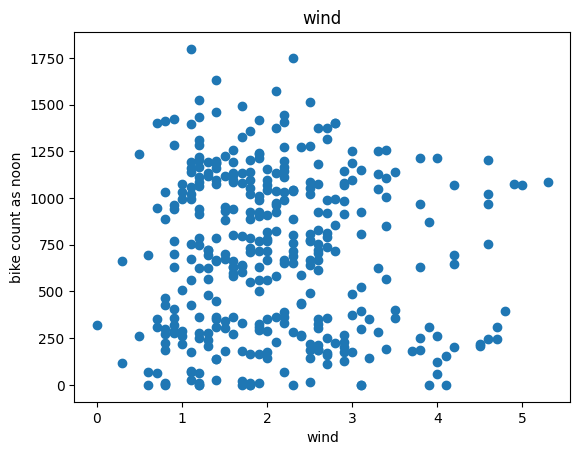

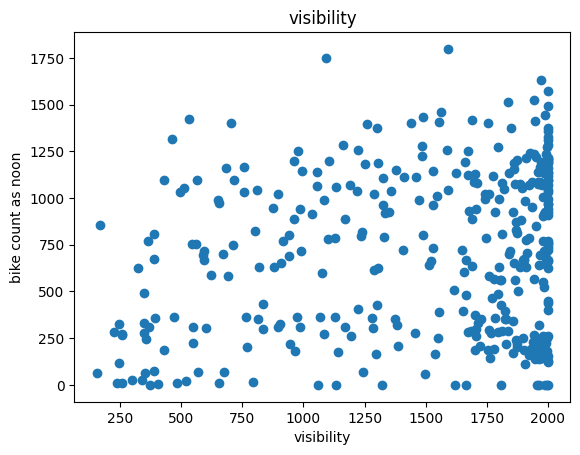

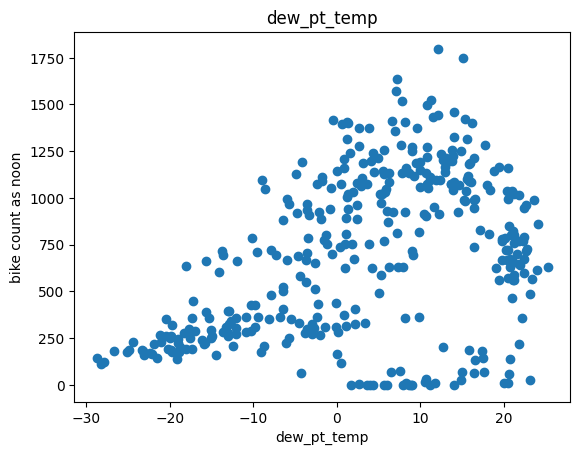

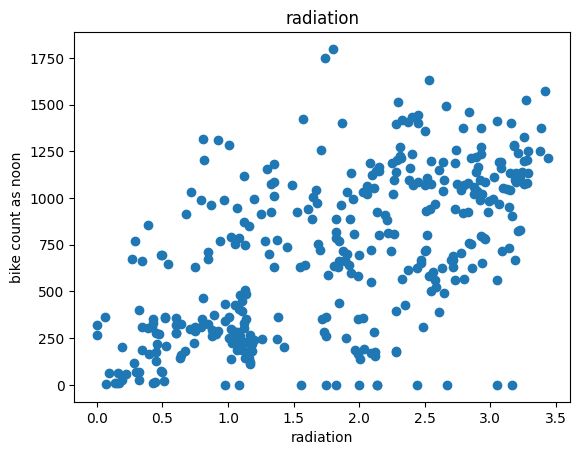

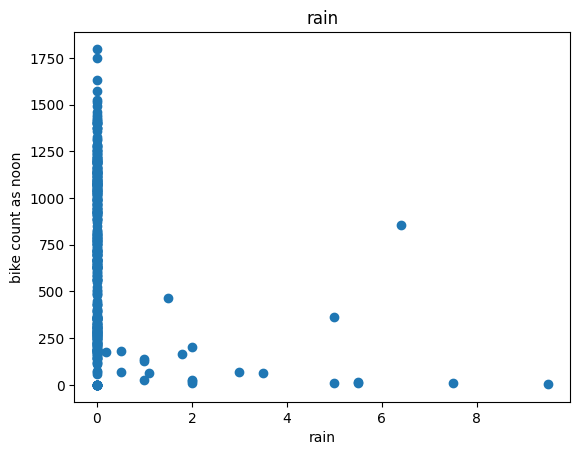

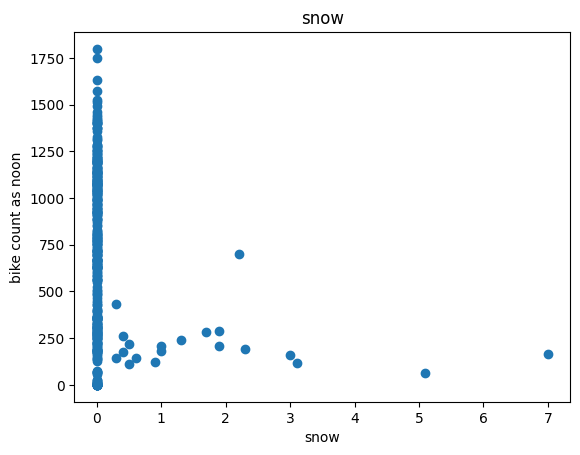

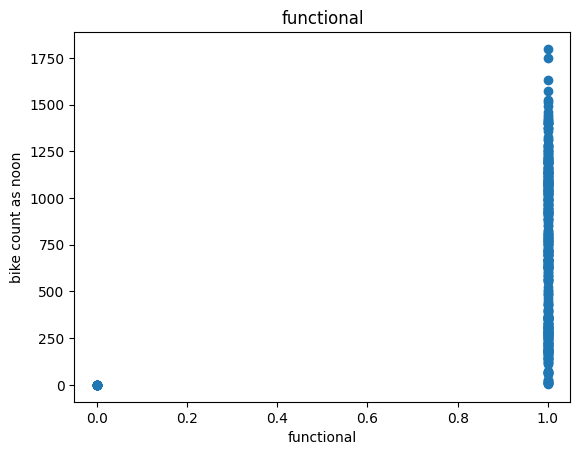

In [28]:
for label in df.columns[1:]:
  plt.scatter(df[label], df['bike_count'])
  plt.title(label)
  plt.ylabel("bike count as noon")
  plt.xlabel(label)
  plt.show()

In [29]:
df = df.drop(["wind", "visibility", "functional"], axis = 1)

In [30]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


# Train/valid/ test datatset


In [31]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [32]:
def get_xy(dataframe, y_label, x_label = None):
  dataframe = copy.deepcopy(dataframe)
  if x_label is None:
    x = dataframe[[c for c in dataframe.columns if c != y_label]].values
  else:
    if len(x_label) == 1:
      x = dataframe[x_label[0]].values.reshape(-1,1)
    else:
      x = dataframe[x_label].values
  y = dataframe[y_label]
  data = np.hstack((x, y.values.reshape(-1,1))) # Corrected from np.hatack
  return data, x, y

In [33]:


_, x_train_temp, y_train_temp = get_xy(train, 'bike_count', x_label = ['temp'])
_, x_val_temp, y_val_temp = get_xy(val, 'bike_count', x_label = ['temp'])
_, x_test_temp, y_test_all = get_xy(test, 'bike_count', x_label = ['temp'])

In [34]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp, y_train_temp)

LinearRegression()

In [35]:
temp_reg.score(x_test_temp, y_test_all)

0.38335871980485936

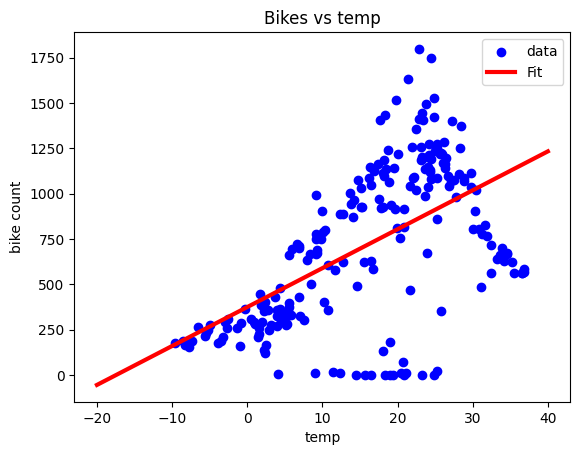

In [36]:
plt.scatter(x_train_temp, y_train_temp, label="data", color='blue')
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(x.numpy().reshape(-1,1)), color='red', label="Fit", linewidth = 3)
plt.legend()
plt.title("Bikes vs temp")
plt.xlabel("temp")
plt.ylabel("bike count")
plt.show()

# Multiple linera regression

In [37]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])
_, x_train_all, y_train_all = get_xy(train, 'bike_count', x_label = df.columns[1:])
_, x_val_all, y_val_all = get_xy(val, 'bike_count', x_label = df.columns[1:])
_, x_test_all, y_test_all = get_xy(test, 'bike_count', x_label = df.columns[1:])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [38]:
all_reg = LinearRegression()
all_reg.fit(x_train_all, y_train_all)

LinearRegression()

In [39]:
all_reg.score(x_test_all, y_test_all)

0.6380239268745826

# regression with neural network

In [40]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel("Epoch")
  plt.ylabel("MSE")
  plt.legend()
  plt.grid(True)
  plt.show()

In [41]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(units=1)
])

In [43]:
temp_nn_model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.1),
                      loss = 'mean_squared_error')

In [45]:
history = temp_nn_model.fit(x_train_temp.reshape(-1), y_train_temp,
                            verbose = 0,
                          epochs=1000,
                          validation_data=(x_val_temp, y_val_temp))

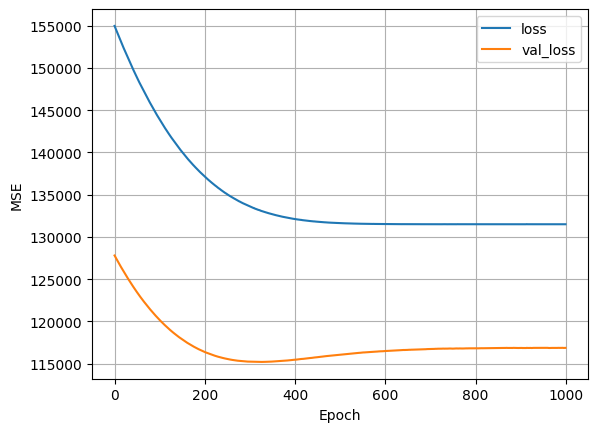

In [46]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


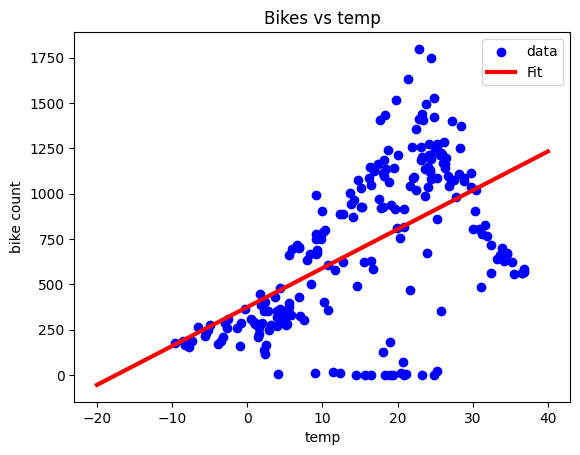

In [47]:
plt.scatter(x_train_temp, y_train_temp, label="data", color='blue')
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(x.numpy().reshape(-1,1)), color='red', label="Fit", linewidth = 3)
plt.legend()
plt.title("Bikes vs temp")
plt.xlabel("temp")
plt.ylabel("bike count")
plt.show()

#Neural network


In [48]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1))
nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss = 'mean_squared_error')

In [49]:
history = nn_model.fit(x_train_temp, y_train_temp,
                            verbose = 0,
                          epochs=1000,
                          validation_data=(x_val_temp, y_val_temp))

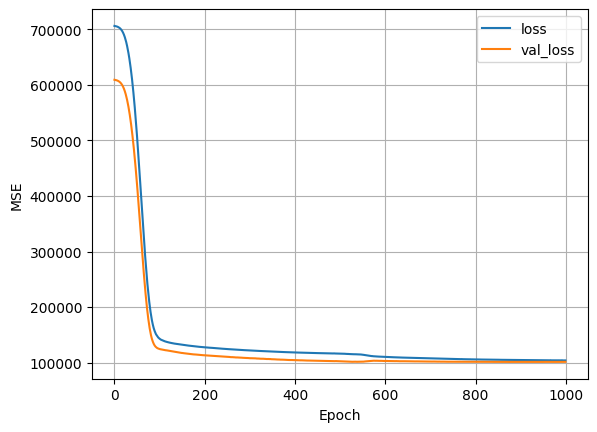

In [50]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


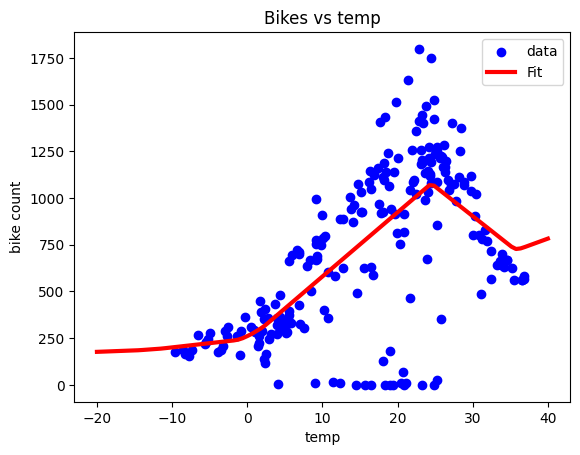

In [51]:
plt.scatter(x_train_temp, y_train_temp, label="data", color='blue')
x = tf.linspace(-20, 40, 100)
plt.plot(x, nn_model.predict(x.numpy().reshape(-1,1)), color='red', label="Fit", linewidth = 3)
plt.legend()
plt.title("Bikes vs temp")
plt.xlabel("temp")
plt.ylabel("bike count")
plt.show()

In [52]:
all_normalizer = tf.keras.layers.Normalization(input_shape=(6,), axis=None)
all_normalizer.adapt(x_train_all)
nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss = 'mean_squared_error')

In [53]:
history = nn_model.fit(x_train_all, y_train_all,
                            verbose = 0,
                          epochs=100,
                          validation_data=(x_val_all, y_val_all))

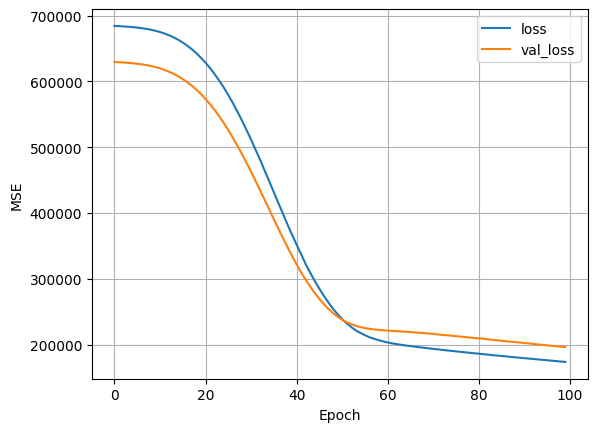

In [54]:
plot_loss(history)


In [57]:
# calulate the MSE for both linear reg and nn
y_pred_rg = all_reg.predict(x_test_all)
y_pred_nn = nn_model.predict(x_test_all)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [59]:
def mse(y_pred, y_real):
  return (np.square(y_pred - y_real)).mean()

In [60]:
mse(y_pred_rg, y_test_all)

np.float64(63497.80783384918)

In [62]:
mse(y_pred_nn.flatten(), y_test_all)

np.float64(145441.1273952531)

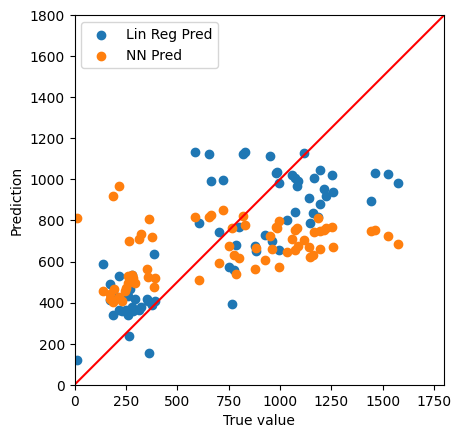

In [66]:
ax = plt.axes(aspect='equal')
plt.scatter(y_test_all, y_pred_rg, label = "Lin Reg Pred")
plt.scatter(y_test_all, y_pred_nn, label = "NN Pred")
plt.xlabel("True value")
plt.ylabel("Prediction")
lims = [0, 1800]
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
_ = plt.plot(lims, lims, c='red')